# Perceptron Implementation

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# weights = "importance" rating of the relationship between neurons
# bias = flat value  for how active that neuron should be regardless of input value and weight 
# lr = learning rate or how big of an adjustment the model makes when it identifies a mistake
class Perceptron:
# Neuron setup
    def __init__ (self, n_inputs, lr=0.1):
        # inserts 1 at index 0. This 1 will be multiplied by the bias weight w[0] 
        self.weights=np.zeros(n_inputs + 1)
        self.lr = lr

    def predict(self, x):
        # prepending the bias
        x_with_bias = np.insert(x, 0, 1)
        # numpy's `dot` is a much more efficient way of calculating the dot product from last chapter of vectors. 
        # ch-1 neuron activation w/ dot product: sum(w * x for w, x in zip(self.weights, inputs))
        # step function, output 1 for non-negative activation, else output 0 (core of binary classification)
        activation = np.dot(self.weights, x_with_bias)
        return 1 if activation >= 0 else 0
    
    # Training algo
    # X = input array
    # y = training labels
    # epochs = learning cycles (hardcoded at 10)
    # xi = one input vector of X
    # yi = corresponding label

    def train(self, X, y, epochs = 10):
        for epoch in range(epochs):
            for xi, yi in zip(X, y):
                # 0 or 1 prediction
                prediction = self.predict(xi)
                # calculate error from label and prediction
                # (-1 = predicted 0 but label is 1, 0 = correct, 1 = predicted 1 but label is 0)
                error = yi - prediction
                # adds bias to inputs
                x_with_bias = np.insert(xi, 0, 1)
                # Updates weights based on learning rate and error
                self.weights += self.lr * error * x_with_bias


In [21]:
# OR truth table as input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1]) 

In [22]:
p = Perceptron(n_inputs = 2, lr = 0.1)
p.train(X, y, epochs=10)

print(f"Learned weights \n(bias, w1, w2)\n{p.weights}")

Learned weights 
(bias, w1, w2)
[-0.1  0.1  0.1]


## Visualization

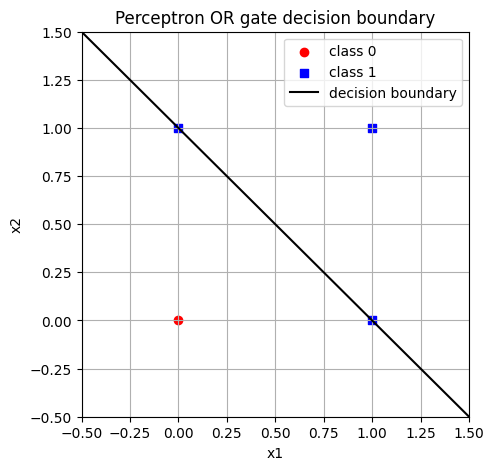

In [25]:
# Scatter plot
plt.figure(figsize=(5, 5))

# class 0 and 1 
for label, marker, color in [(0, "o", "red"), (1, "s", "blue")]:
    idx = (y == label)
    plt.scatter(X[idx, 0], X[idx, 1],
                 c=color, 
                 marker=marker, 
                 label=f"class {label}")
    
# decision boundary from perceptron weights
# w0 = bias
w0, w1, w2 = p.weights


x1_vals = np.linspace(-0.5, 1.5, 100)

# divide by zero error handling
if w2 != 0:
    x2_vals = -(w0 + w1 * x1_vals) / w2
    plt.plot(x1_vals, x2_vals, "k-", label="decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.legend()
plt.grid(True)
plt.title("Perceptron OR gate decision boundary")
plt.show()


In [26]:
print("Perceptron OR gate behavior after training:")
for xi, yi in zip(X, y):
    pred = p.predict(xi)
    print(f"input {xi} -> predicted {pred}, expected {yi}.")

Perceptron OR gate behavior after training:
input [0 0] -> predicted 0, expected 0.
input [0 1] -> predicted 1, expected 1.
input [1 0] -> predicted 1, expected 1.
input [1 1] -> predicted 1, expected 1.
